# Nifty 50 — Yang–Zhang realized volatility (1 year)

Daily OHLCV is downloaded from **Yahoo Finance** (`^NSEI`). The [Yang–Zhang (2000)](https://doi.org/10.1016/S0304-405X(00)00061-0) estimator combines overnight variance, open-to-close variance, and the Rogers–Satchell range-based term, with a bias correction via the weight \(k\).

**Requirements:** `pip install yfinance pandas numpy matplotlib`

In [29]:
# pip install yfinance pandas numpy matplotlib arch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [30]:
TICKER = "^NSEI"
PERIOD = "1y"

raw = yf.download(TICKER, period=PERIOD, interval="1d", auto_adjust=False, progress=False)
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.droplevel(1)

ohlcv = raw[["Open", "High", "Low", "Close", "Volume"]].copy()
ohlcv = ohlcv.dropna(how="any")
ohlcv.index = pd.to_datetime(ohlcv.index)
if getattr(ohlcv.index, "tz", None) is not None:
    ohlcv.index = ohlcv.index.tz_convert(None)
ohlcv.head()

Price,Open,High,Low,Close,Volume
Date,,,,,
2025-04-15,23368.349609,23368.349609,23207.000000,23328.550781,388300
2025-04-16,23344.099609,23452.199219,23273.050781,23437.199219,348400
2025-04-17,23401.849609,23872.349609,23298.550781,23851.650391,505300
2025-04-21,23949.150391,24189.550781,23903.650391,24125.550781,406100
2025-04-22,24185.400391,24242.599609,24072.000000,24167.250000,440900


In [31]:
def yang_zhang_realized_vol(
    df: pd.DataFrame,
    window: int = 20,
    trading_days_per_year: int = 252,
) -> pd.Series:
    """
    Rolling Yang–Zhang volatility (annualized).

    sigma^2_YZ = sigma^2_o + k * sigma^2_c + (1 - k) * sigma^2_rs

    - sigma^2_o: variance of overnight log returns ln(O_t / C_{t-1})
    - sigma^2_c: variance of open-to-close log returns ln(C_t / O_t)
    - sigma^2_rs: mean Rogers–Satchell component in the window
    - k = 0.34 / (1.34 + (n + 1) / (n - 1)), n = window length
    """
    o = df["Open"].astype(float)
    h = df["High"].astype(float)
    low = df["Low"].astype(float)
    c = df["Close"].astype(float)

    c_prev = c.shift(1)
    overnight = np.log(o / c_prev)
    open_close = np.log(c / o)

    log_hc = np.log(h / c)
    log_ho = np.log(h / o)
    log_lc = np.log(low / c)
    log_lo = np.log(low / o)
    rogers_satchell = log_hc * log_ho + log_lc * log_lo

    n = window
    if n < 2:
        raise ValueError("window must be >= 2")
    k = 0.34 / (1.34 + (n + 1) / (n - 1))

    var_o = overnight.rolling(window).var()
    var_c = open_close.rolling(window).var()
    var_rs = rogers_satchell.rolling(window).mean()

    yz_var = var_o + k * var_c + (1.0 - k) * var_rs
    yz_vol = np.sqrt(np.maximum(yz_var, 0.0)) * np.sqrt(trading_days_per_year)
    return yz_vol.rename("yang_zhang_ann_vol")


ROLLING_WINDOW = 7 #20
yz = yang_zhang_realized_vol(ohlcv, window=ROLLING_WINDOW)
log_ret = np.log(ohlcv["Close"] / ohlcv["Close"].shift(1)).rename("log_return")
yz.tail()

Date
2026-04-08    0.333157
2026-04-09    0.331467
2026-04-10    0.305365
2026-04-13    0.302275
2026-04-15    0.283268
Name: yang_zhang_ann_vol, dtype: float64

/var/folders/zj/f_18sgh92t915rctldctn_z80000gn/T/ipykernel_58963/927801895.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


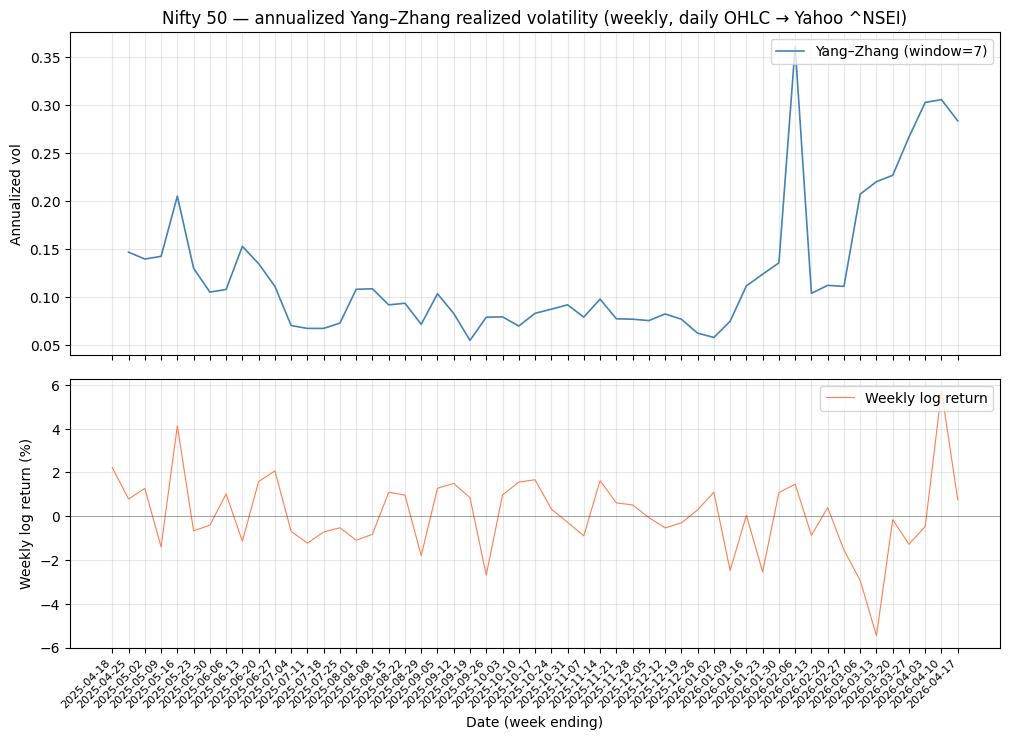

In [32]:
# Weekly aggregation for plotting (Fri = end of NSE trading week)
W_FREQ = "W-FRI"
yz_w = yz.resample(W_FREQ).last()
log_ret_w = log_ret.resample(W_FREQ).sum()

fig, (ax0, ax1) = plt.subplots(
    2, 1, figsize=(12, 8), sharex=True, gridspec_kw={"height_ratios": [1.2, 1], "hspace": 0.08}
)
ax0.plot(yz_w.index, yz_w.values, color="steelblue", linewidth=1.2, label=f"Yang–Zhang (window={ROLLING_WINDOW})")
ax0.set_title("Nifty 50 — annualized Yang–Zhang realized volatility (weekly, daily OHLC → Yahoo ^NSEI)")
ax0.set_ylabel("Annualized vol")
ax0.grid(True, alpha=0.3)
ax0.legend(loc="upper right")

ax1.plot(log_ret_w.index, log_ret_w.values * 100, color="coral", linewidth=0.8, label="Weekly log return")
ax1.axhline(0, color="black", linewidth=0.5, alpha=0.4)
ax1.set_ylabel("Weekly log return (%)")
ax1.set_xlabel("Date (week ending)")
ax1.grid(True, alpha=0.3)
ax1.legend(loc="upper right")

# One date label per weekly point (shared x-axis)
tick_labels = [x.strftime("%Y-%m-%d") for x in yz_w.index]
ax1.set_xticks(yz_w.index)
ax1.set_xticklabels(tick_labels, rotation=45, ha="right", fontsize=8)

plt.tight_layout()
plt.show()

                     Constant Mean - GARCH Model Results                      
Dep. Variable:               r_scaled   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -176.531
Distribution:                  Normal   AIC:                           361.062
Method:            Maximum Likelihood   BIC:                           374.174
                                        No. Observations:                  196
Date:                Wed, Apr 15 2026   Df Residuals:                      195
Time:                        17:39:44   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu             0.0231  4.586e-02      0.503      0.615 [-6.68

/var/folders/zj/f_18sgh92t915rctldctn_z80000gn/T/ipykernel_58963/2267197419.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


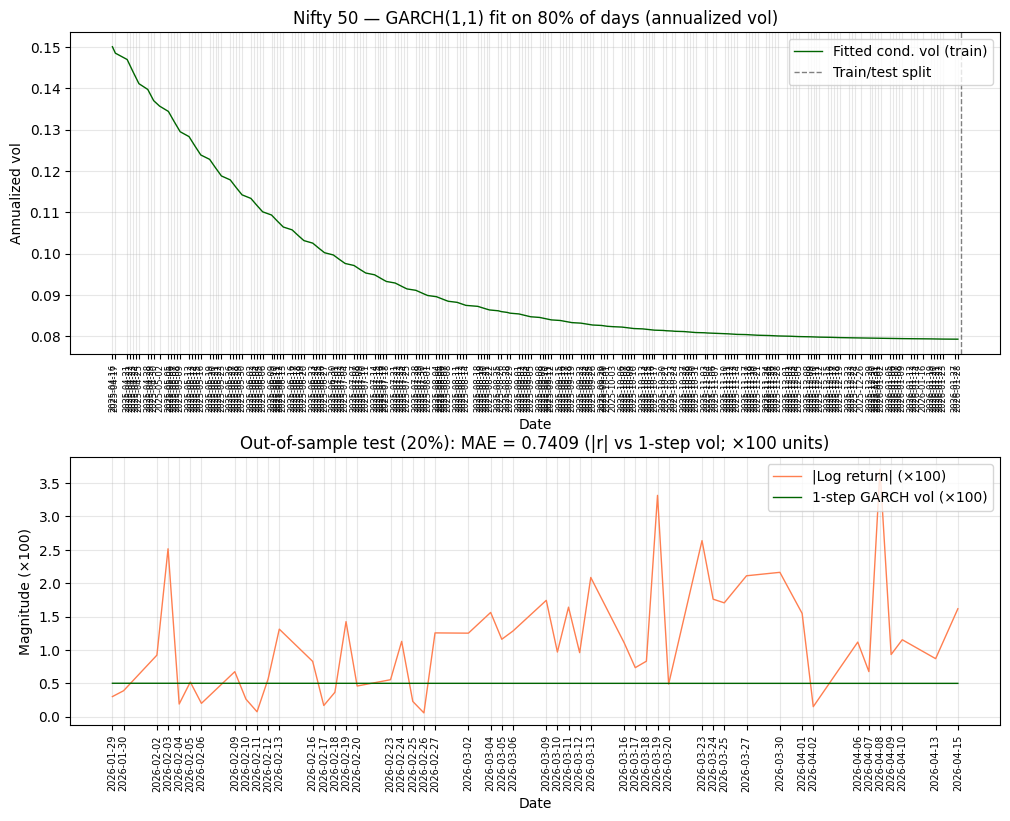

In [33]:
# GARCH(1,1): 80% train / 20% test; 1-step-ahead vol on test vs |r|; MAE
# Multi-step forecasts from one origin quickly approach unconditional variance → often flat across h.
# pip install arch
from arch import arch_model

r_pct = (log_ret.dropna().astype(float) * 100.0).rename("r_scaled")
log_ret_a = log_ret.dropna().astype(float).reindex(r_pct.index)

train_frac = 0.8
split_i = int(len(r_pct) * train_frac)
if split_i < 100 or len(r_pct) - split_i < 20:
    raise ValueError("Need enough observations in train and test; lengthen PERIOD or adjust train_frac.")

r_train, r_test = r_pct.iloc[:split_i], r_pct.iloc[split_i:]
lr_train, lr_test = log_ret_a.iloc[:split_i], log_ret_a.iloc[split_i:]

am = arch_model(r_train, mean="Constant", vol="Garch", p=1, q=1, dist="normal")
garch_res = am.fit(disp="off")
print(garch_res.summary())

par = garch_res.params
mu = float(par["mu"])
omega = float(par["omega"])
alpha = float(par["alpha[1]"])
beta = float(par["beta[1]"])
uncond_var = omega / (1.0 - alpha - beta) if alpha + beta < 1 else np.nan
print(f"\nUnconditional variance (scaled series): {uncond_var:.6f}  (multi-step forecasts converge toward this)")

# 1-step-ahead conditional variances on the test window (GARCH recursion; params fixed from train)
sigma2 = np.empty(len(r_test), dtype=float)
eps_prev = float(r_train.iloc[-1] - mu)
h_prev = float(garch_res.conditional_volatility.iloc[-1] ** 2)
for t in range(len(r_test)):
    h_t = omega + alpha * (eps_prev**2) + beta * h_prev
    sigma2[t] = h_t
    eps_prev = float(r_test.iloc[t] - mu)
    h_prev = h_t

fc_vol_logret = np.sqrt(np.maximum(sigma2, 0.0)) / 100.0
realized_abs = np.abs(lr_test.values)
mae = np.mean(np.abs(realized_abs - fc_vol_logret))
print(f"\nTest period: {lr_test.index[0].date()} → {lr_test.index[-1].date()}  (n={len(lr_test)})")
print(f"MAE (|daily log return| vs 1-step GARCH vol forecast, same units): {mae:.6f}")

# Train-only in-sample annualized vol (for plot)
cond_train = garch_res.conditional_volatility / 100.0
garch_ann_train = cond_train * np.sqrt(252)

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(12, 9), sharex=False, gridspec_kw={"height_ratios": [1.2, 1], "hspace": 0.35})
ax0.plot(r_train.index, garch_ann_train.values, color="darkgreen", linewidth=1.0, label="Fitted cond. vol (train)")
ax0.axvline(r_test.index[0], color="gray", linestyle="--", linewidth=1, label="Train/test split")
ax0.set_title(f"Nifty 50 — GARCH(1,1) fit on {train_frac:.0%} of days (annualized vol)")
ax0.set_ylabel("Annualized vol")
ax0.set_xlabel("Date")
ax0.grid(True, alpha=0.3)
ax0.legend(loc="upper right")
ax0.set_xticks(r_train.index)
ax0.set_xticklabels([x.strftime("%Y-%m-%d") for x in r_train.index], rotation=90, ha="center", fontsize=6)

ax1.plot(lr_test.index, realized_abs * 100, color="coral", linewidth=1.0, label="|Log return| (×100)")
ax1.plot(lr_test.index, fc_vol_logret * 100, color="darkgreen", linewidth=1.0, label="1-step GARCH vol (×100)")
ax1.set_title(
    f"Out-of-sample test ({(1 - train_frac) * 100:.0f}%): MAE = {mae * 100:.4f} (|r| vs 1-step vol; ×100 units)"
)
ax1.set_ylabel("Magnitude (×100)")
ax1.set_xlabel("Date")
ax1.grid(True, alpha=0.3)
ax1.legend(loc="upper right")
ax1.set_xticks(lr_test.index)
ax1.set_xticklabels([x.strftime("%Y-%m-%d") for x in lr_test.index], rotation=90, ha="center", fontsize=7)

plt.tight_layout()
plt.show()

In [34]:
# AAPL: 1-week (5 trading days) rolling z-score of daily returns
AAPL_TICKER = "AAPL"
aapl_raw = yf.download(AAPL_TICKER, period="1y", interval="1d", auto_adjust=False, progress=False)
if isinstance(aapl_raw.columns, pd.MultiIndex):
    aapl_raw.columns = aapl_raw.columns.droplevel(1)

aapl_close = aapl_raw["Close"].dropna().astype(float)
aapl_ret = np.log(aapl_close / aapl_close.shift(1)).rename("aapl_log_return")

WEEK_WINDOW = 5
aapl_roll_mean = aapl_ret.rolling(WEEK_WINDOW).mean()
aapl_roll_std = aapl_ret.rolling(WEEK_WINDOW).std()
aapl_z_1w = ((aapl_ret - aapl_roll_mean) / aapl_roll_std).rename("aapl_1w_zscore")

aapl_z_1w.dropna().tail(10)

Date
2026-04-01    0.281854
2026-04-02   -0.072472
2026-04-06    0.252641
2026-04-07   -1.471242
2026-04-08    1.088284
2026-04-09    0.150484
2026-04-10   -0.227229
2026-04-13   -0.337845
2026-04-14   -0.544575
2026-04-15    1.467648
Name: aapl_1w_zscore, dtype: float64

In [35]:
# Today's z-score using a given spot
spot = 260.75

# Use last available close in downloaded AAPL history as reference
prev_close = float(aapl_close.iloc[-1])
ret_today = np.log(spot / prev_close)

# Baseline: most recent 1-week (5 trading days) of historical daily log returns
WEEK_WINDOW = 5
baseline = aapl_ret.dropna().iloc[-WEEK_WINDOW:]
mu_1w = baseline.mean()
sigma_1w = baseline.std()

z_today = (ret_today - mu_1w) / sigma_1w

print(f"Prev close used: {prev_close:.2f}")
print(f"Spot used: {spot:.2f}")
print(f"Today's log return: {ret_today:.6f}")
print(f"1-week mean return: {mu_1w:.6f}")
print(f"1-week std return: {sigma_1w:.6f}")
print(f"Today's 1-week z-score: {z_today:.4f}")

Prev close used: 262.15
Spot used: 260.75
Today's log return: -0.005354
1-week mean return: 0.002495
1-week std return: 0.006984
Today's 1-week z-score: -1.1239


In [ ]:
# Plot: AAPL 1-week rolling z-score of daily returns
z_plot = aapl_z_1w.dropna()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(z_plot.index, z_plot.values, color="royalblue", linewidth=1.1, label="AAPL 1-week z-score")
ax.axhline(0, color="black", linewidth=0.8, alpha=0.7)
ax.axhline(2, color="crimson", linestyle="--", linewidth=1.0, alpha=0.8, label="+2")
ax.axhline(-2, color="crimson", linestyle="--", linewidth=1.0, alpha=0.8, label="-2")

# Highlight the z-score computed from the provided spot
today_label = pd.Timestamp.today().normalize()
ax.scatter([today_label], [z_today], color="darkorange", s=55, zorder=5, label=f"Spot z-score ({spot:.2f})")

ax.set_title("AAPL daily return z-score (1-week rolling window)")
ax.set_ylabel("Z-score")
ax.set_xlabel("Date")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()